# Setup

In [15]:
from scipy.stats import median_abs_deviation

import sys
sys.path.insert(0, '/home/workspace/mm_bm_chip_organoids')
sys.path.insert(0, '/home/workspace/')

from py_util import *
from utilities import *

hdir = '/home/workspace'
wdir = hdir + "/mm_bm_chip_organoids/EXP-01244"
objdir = wdir + "/processing/objects/"
degdir = wdir + "/deg_list/"
pltdir = wdir + "/analysis/plots/"

adata = sc.read_h5ad(objdir + "not_ds_wk4_starters_adata.h5ad")

# Sample Type UMAP

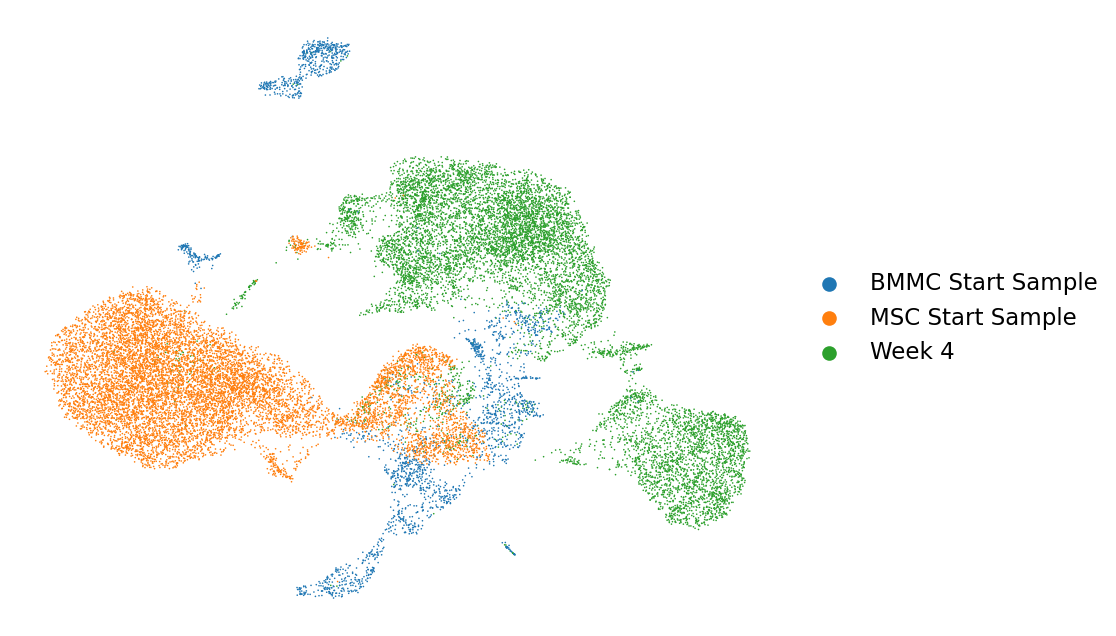

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(10, 8))


sc.pl.umap(
    adata,
    color='name',
    ax = ax,
    # legend_loc='best',
    title='',
    show=False,
    frameon=False
)

plt.savefig(pltdir + 'not_ds_trans_wk4_starters_sample_type_umap_plot.png', transparent=True, bbox_inches='tight')
plt.savefig(pltdir + 'not_ds_wk4_starters_sample_type_umap_plot.png', transparent=False, bbox_inches='tight')

/home/workspace/environment/mm_py_env/lib/python3.9/site-packages/scanpy/_settings.py:488: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  IPython.display.set_matplotlib_formats(*ipython_format)


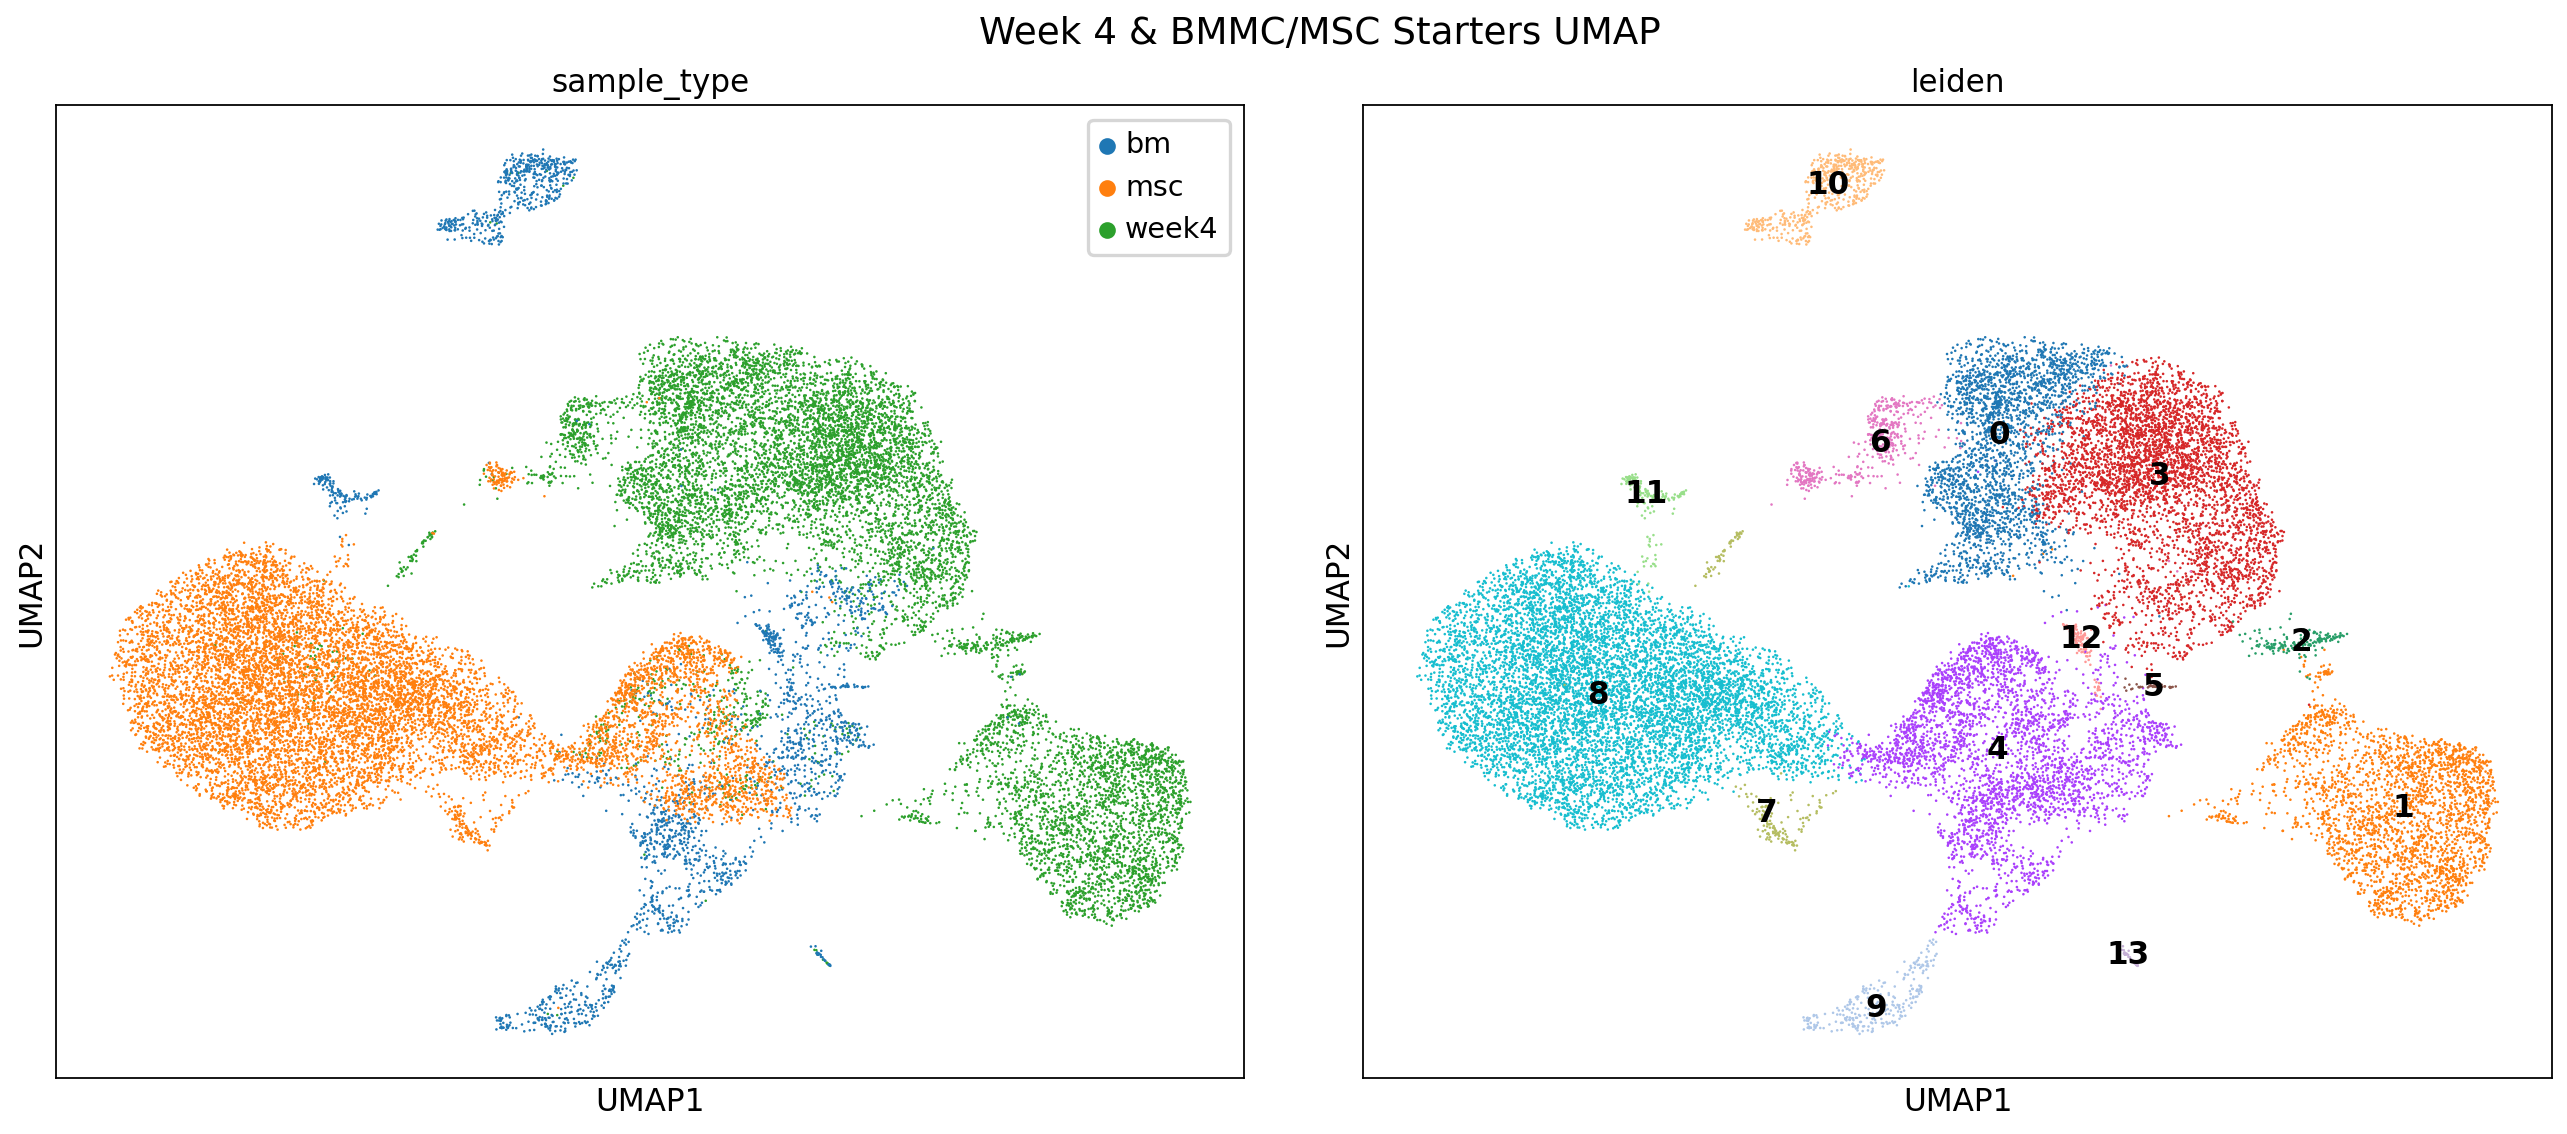

In [43]:
fig, ax = plt.subplots(1, 2, figsize=(20, 8), gridspec_kw={'wspace': 0.1})

sc.pl.umap(
    adata,
    color='sample_type',
    ax = ax[0],
    legend_loc='best',
    show=False
)

sc.pl.umap(
    adata,
    color='leiden',
    ax = ax[1],
    legend_loc='on data',
    show=False
)

fig.suptitle('Week 4 & BMMC/MSC Starters UMAP', x=0.575)

plt.savefig(pltdir + 'not_ds_trans_wk4_starters_umap_plot.png', transparent=True, bbox_inches='tight')
plt.savefig(pltdir + 'not_ds_wk4_starters_umap_plot.png', transparent=False, bbox_inches='tight')

# DEG's

In [ ]:
ranking = adata.uns['rank_genes_groups']
gene_names = ranking['names']
gene_scores = ranking['scores']
gene_pvals_adj = ranking['pvals_adj']
clusters = gene_names.dtype.names

de_genes = []
for cluster in clusters:
    names = gene_names[cluster]
    scores = gene_scores[cluster]
    pvals_adj = gene_pvals_adj[cluster]
    for name, score, pval_adj in zip(names, scores, pvals_adj):
        if pval_adj < 0.05:
            de_genes.append((cluster, name, score, pval_adj))

df_de_genes = pd.DataFrame(de_genes, columns=['Cluster', 'Gene', 'Score', 'Adjusted p-value'])
df_de_genes.to_csv(degdir + 'downsampled_wk2_4_organoids_DEGs.csv', index=False)

In [3]:
ranking = adata.uns['rank_genes_groups']
gene_names = ranking['names']
gene_z_scores = ranking['scores']
gene_logfold = ranking['logfoldchanges']
gene_pvals_adj = ranking['pvals_adj']
clusters = gene_names.dtype.names

df_de_genes = pd.DataFrame()

for cluster in clusters:
    names = gene_names[cluster]
    logfold = gene_logfold[cluster]
    z_scores = gene_z_scores[cluster]
    pvals_adj = gene_pvals_adj[cluster]

    # # Top 40 genes
    # n_genes = 40
    
    # cluster_df = pd.DataFrame({
    #     f'C{cluster}_names': names[:n_genes],
    #     f'C{cluster}_logfold': logfold[:n_genes],
    #     f'C{cluster}_pvals_adj': pvals_adj[:n_genes],
    #     f'C{cluster}_z_score': z_scores[:n_genes]
    # })

    # All genes 
    cluster_df = pd.DataFrame({
        f'C{cluster}_names': names,
        f'C{cluster}_logfold': logfold,
        f'C{cluster}_pvals_adj': pvals_adj,
        f'C{cluster}_z_score': z_scores
    })

    if df_de_genes.empty:
        df_de_genes = cluster_df
    else:
        df_de_genes = pd.merge(df_de_genes, cluster_df, left_index=True, right_index=True, how='outer')

df_de_genes.to_csv(degdir + 'not_ds_wk4_starters_DEGs.csv', index=False)

# Plotting ranked genes per cluster

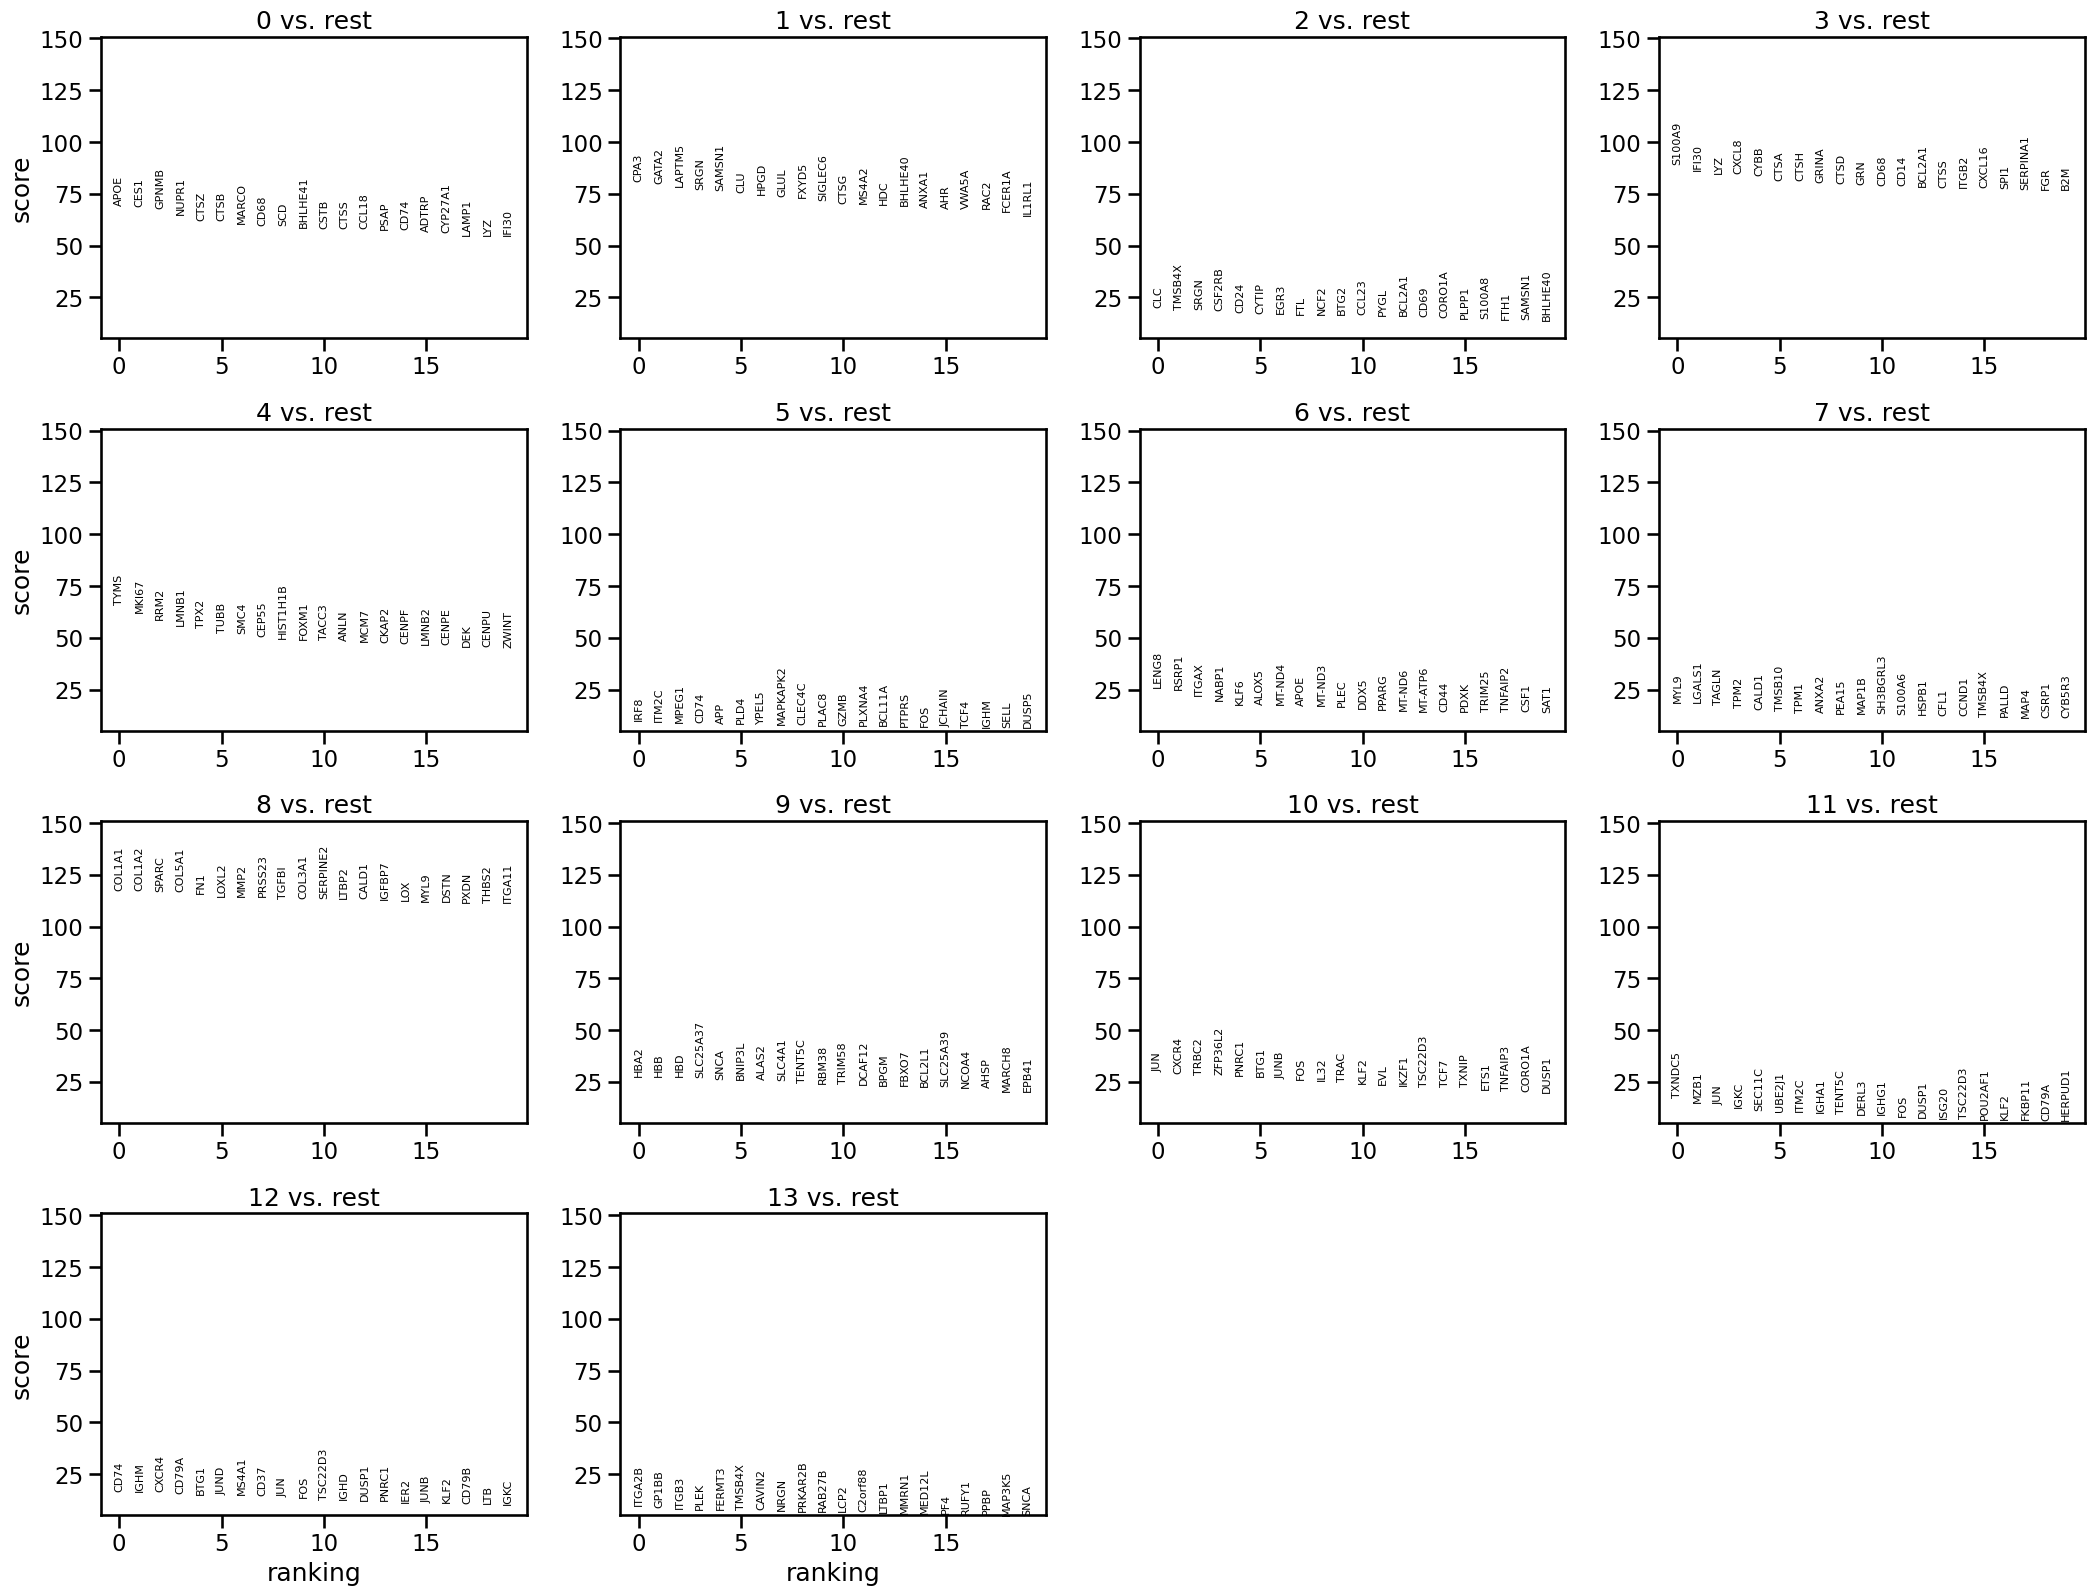

In [17]:
sc.pl.rank_genes_groups(
    adata
)

# PAGA trajectory

/home/workspace/environment/mm_py_env/lib/python3.9/site-packages/scanpy/_settings.py:488: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  IPython.display.set_matplotlib_formats(*ipython_format)


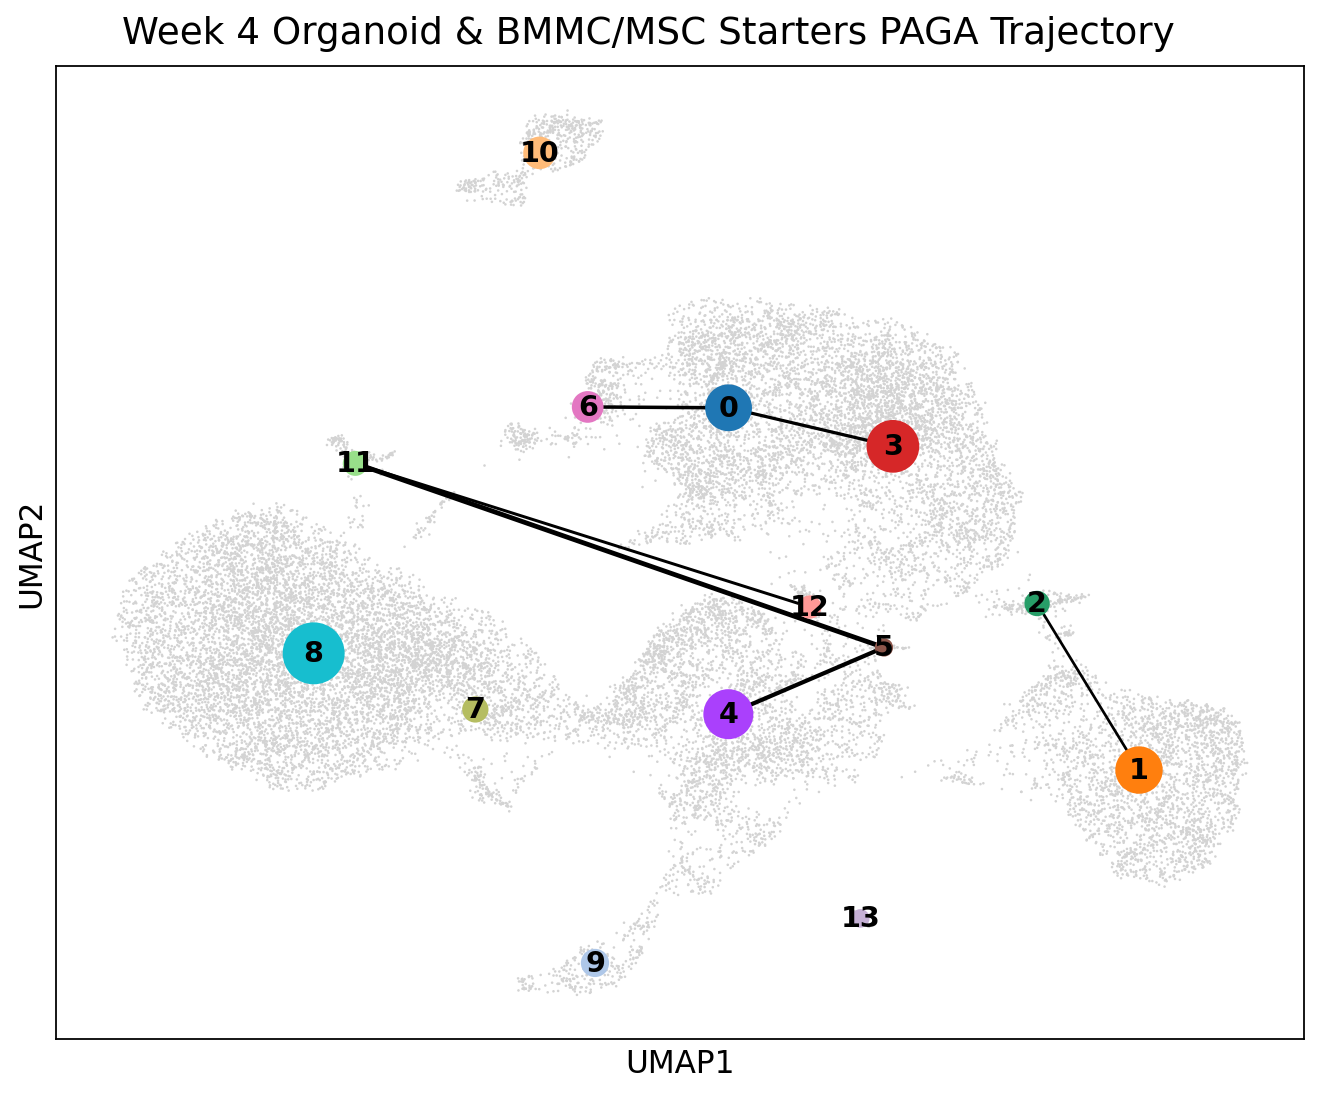

In [37]:
pos = pd.DataFrame(adata.obsm["X_umap"], index=adata.obs_names)
pos["group"] = adata.obs[adata.uns["paga"]["groups"]]
pos = pos.groupby("group", observed=True).mean()

fig, ax = plt.subplots(1, 1, figsize=(10, 8))

sc.settings.set_figure_params(transparent=True)

sc.pl.umap(
    adata,
    show=False,
    ax=ax
)

sc.pl.paga(
    adata,
    color='leiden',
    threshold=0.2,
    node_size_scale=1,
    edge_width_scale=0.7,
    pos=pos.values,
    random_state=0,
    show=False,
    ax=ax
)

fig.suptitle('Week 4 Organoid & BMMC/MSC Starters PAGA Trajectory', y=0.95, x=0.55)

plt.savefig(pltdir + 'not_ds_trans_wk4_starters_paga_plot.png', transparent=True, bbox_inches='tight')
plt.savefig(pltdir + 'not_ds_wk4_starters_paga_plot.png', transparent=False, bbox_inches='tight')

# PAGA trajectory res 0.8

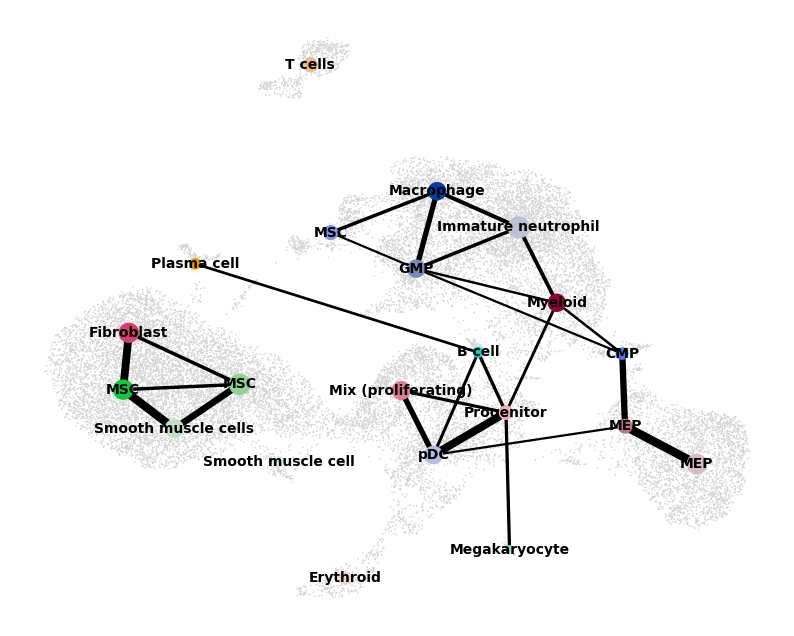

In [47]:
tmp = adata.copy()
res = 0.8
res_key = f"leiden_{str(res).replace('.', '_')}"

# Convert the keys in your dictionary to match the actual data type in your leiden clusters
leiden_categories = list(map(str, tmp.obs[res_key].cat.categories))
celltypes = {
    '0': 'Macrophage',
    '1': 'GMP',
    '2': 'Immature neutrophil',
    '3': 'MEP',
    '4': 'MEP',
    '5': 'Myeloid',
    '6': 'CMP',
    '7': 'MSC',
    '8': 'pDC',
    '9': 'Progenitor',
    '10': 'Mix (proliferating)',
    '11': 'Fibroblast',
    '12': 'MSC',
    '13': 'MSC',
    '14': 'Smooth muscle cells',
    '15': 'Erythroid',
    '16': 'T cells',
    '17': 'Plasma cell',
    '18': 'B cell',
    '19': 'Megakaryocyte',
    '20': 'Smooth muscle cell'
}

adjusted_celltypes = {}
for cat in leiden_categories:
    if cat in celltypes:
        adjusted_celltypes[cat] = celltypes[cat]
    else:
        adjusted_celltypes[cat] = f"Cluster {cat}"

tmp.obs['leiden'] = tmp.obs[res_key].copy()
tmp.uns['leiden'] = tmp.uns[res_key].copy()
sc.tl.paga(tmp, groups='leiden')

pos = pd.DataFrame(tmp.obsm["X_umap"], index=tmp.obs_names)
pos["group"] = tmp.obs[tmp.uns["paga"]["groups"]]
pos = pos.groupby("group", observed=True).mean()

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
sc.pl.umap(
    tmp,
    show=False,
    frameon=False,
    ax=ax
)

# Let's try a different approach by creating a list of labels in the same order as the categories
leiden_categories = list(tmp.obs['leiden'].cat.categories)
label_list = [adjusted_celltypes.get(str(cat), f"Cluster {cat}") for cat in leiden_categories]

sc.pl.paga(
    tmp,
    color='leiden',
    labels=label_list,  # Use a list instead of a dictionary
    title='',
    threshold=0.2,
    node_size_scale=1,
    edge_width_scale=0.7,
    pos=pos.values,
    random_state=0,
    show=False,
    ax=ax,
    frameon=False,
    fontsize=10
)

plt.savefig(pltdir + 'not_ds_wk4_starters_labeled_res_0.8_paga_plot.png', bbox_inches='tight')

# Generate PAGA and DEG's for leiden resolution 0.5 - 0.9

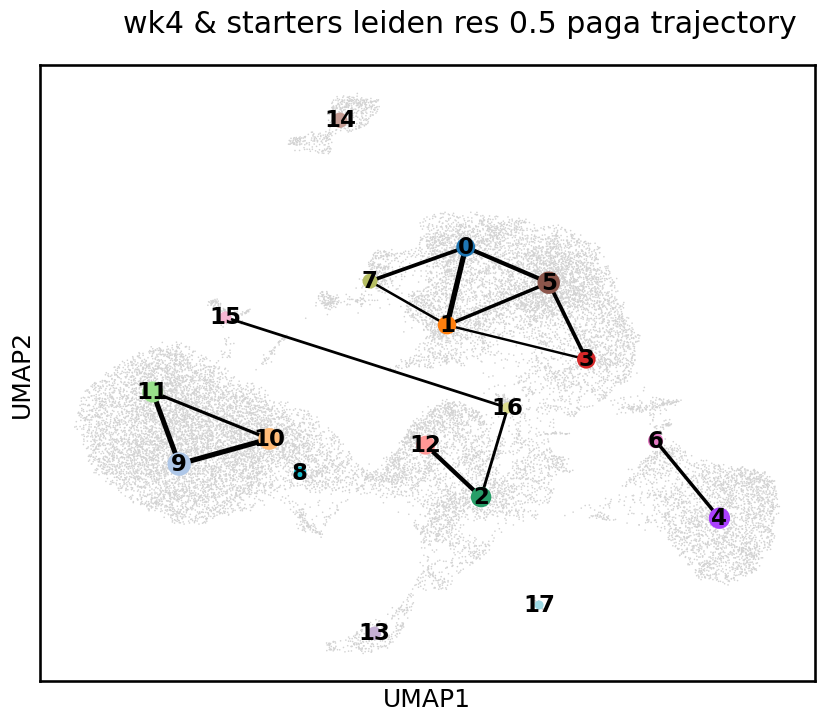

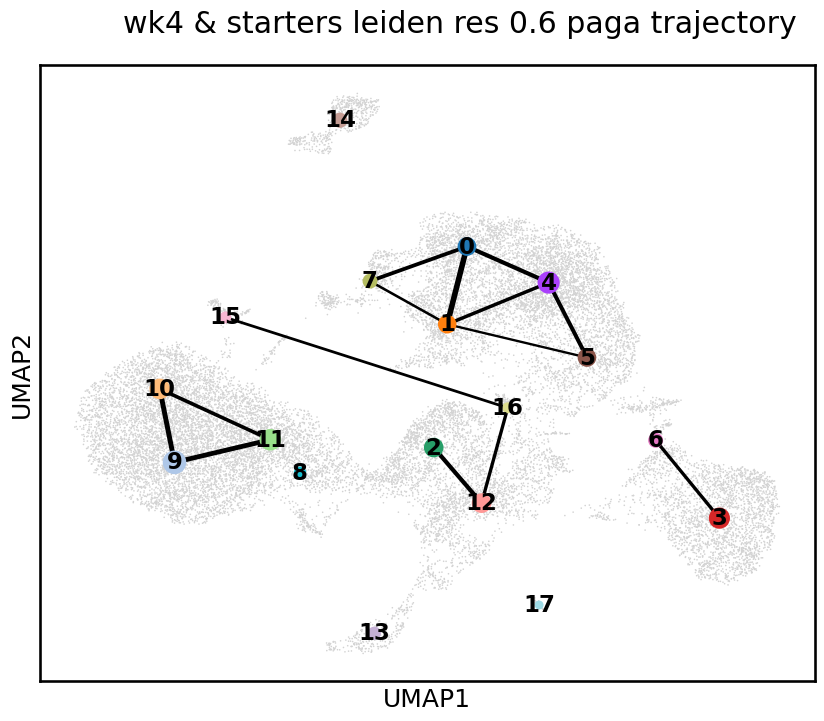

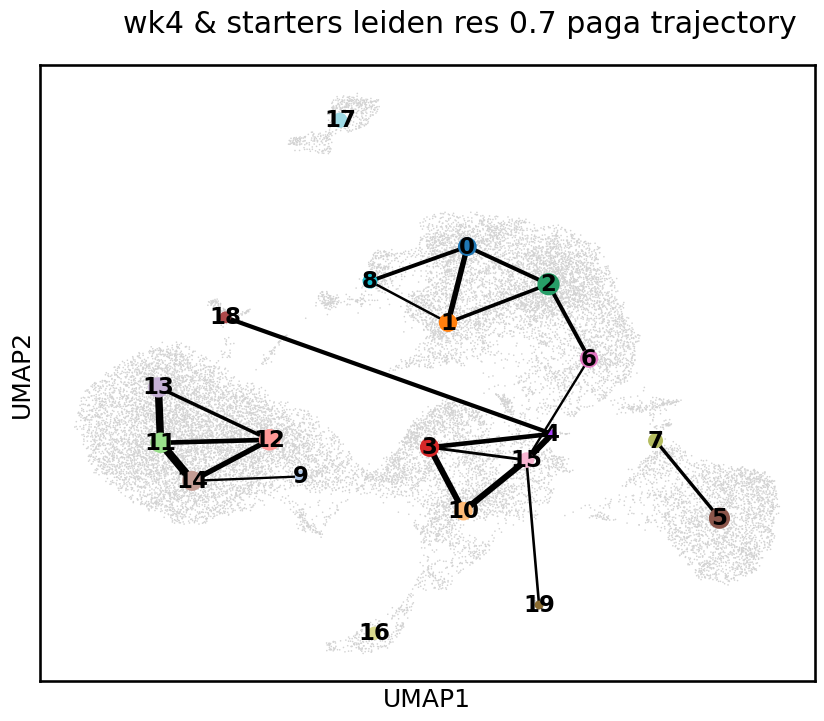

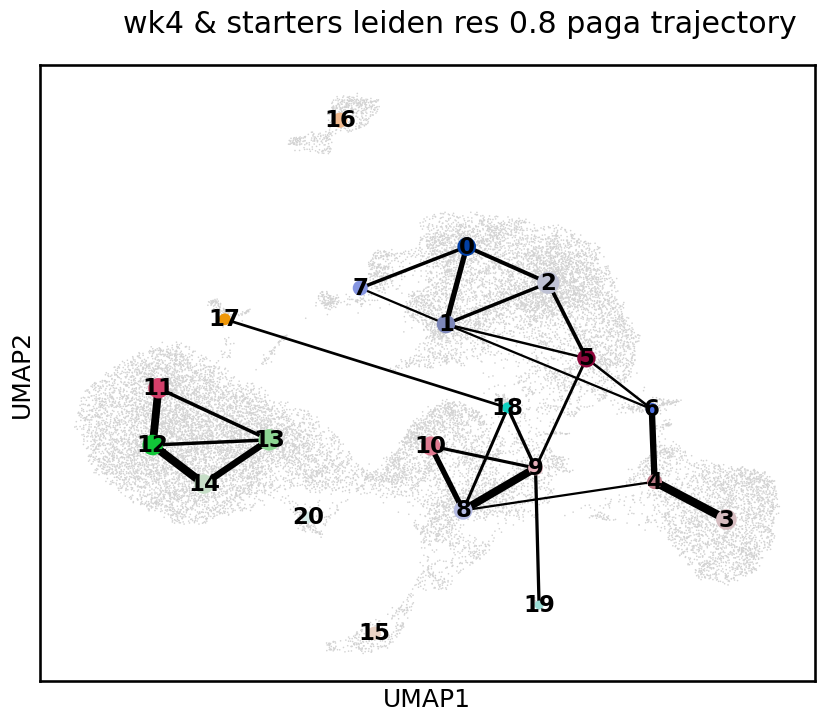

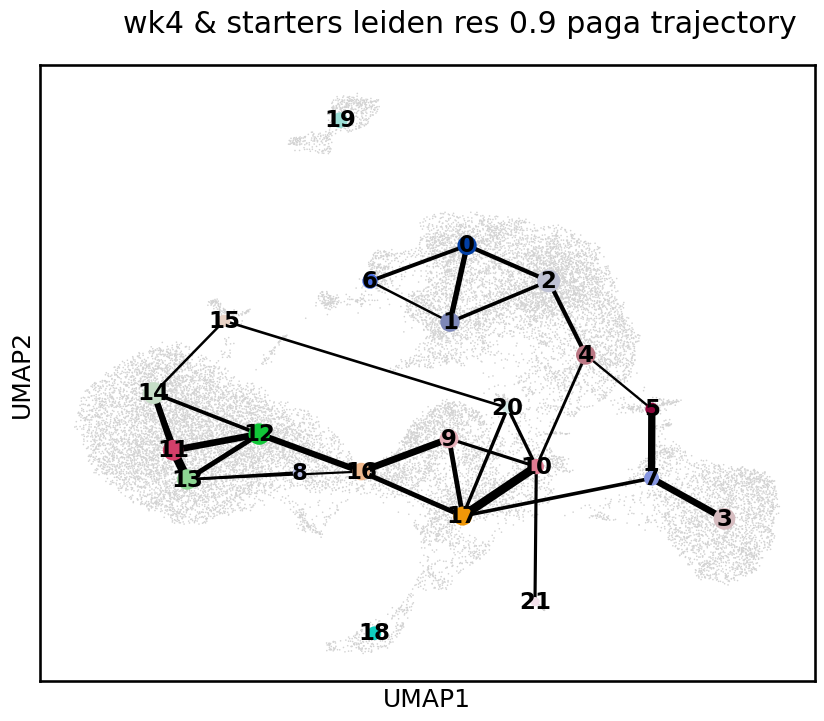

In [24]:
res_range = np.round(np.arange(0.5, 1.0, 0.1), 1)

for res in res_range:
    tmp = adata.copy()
    
    res_key = f"leiden_{str(res).replace('.', '_')}"
    
    tmp.obs['leiden'] = tmp.obs[res_key].copy()
    tmp.uns['leiden'] = tmp.uns[res_key].copy()

    sc.tl.paga(tmp, groups='leiden')
    sc.tl.rank_genes_groups(tmp, 'leiden', method='wilcoxon')


    
    ranking = tmp.uns['rank_genes_groups']
    gene_names = ranking['names']
    gene_z_scores = ranking['scores']
    gene_logfold = ranking['logfoldchanges']
    gene_pvals_adj = ranking['pvals_adj']
    clusters = gene_names.dtype.names
    
    df_de_genes = pd.DataFrame()
    
    for cluster in clusters:
        names = gene_names[cluster]
        logfold = gene_logfold[cluster]
        z_scores = gene_z_scores[cluster]
        pvals_adj = gene_pvals_adj[cluster]

        cluster_df = pd.DataFrame({
            f'C{cluster}_names': names,
            f'C{cluster}_logfold': logfold,
            f'C{cluster}_pvals_adj': pvals_adj,
            f'C{cluster}_z_score': z_scores
        })
    
        if df_de_genes.empty:
            df_de_genes = cluster_df
        else:
            df_de_genes = pd.merge(df_de_genes, cluster_df, left_index=True, right_index=True, how='outer')
    
    df_de_genes.to_csv(degdir + f'not_ds_wk4_starters_res_{res}_DEGs.csv', index=False)



    fig, ax = plt.subplots(1, 1, figsize=(10, 8))

    pos = pd.DataFrame(tmp.obsm["X_umap"], index=tmp.obs_names)
    pos["group"] = tmp.obs[tmp.uns["paga"]["groups"]]
    pos = pos.groupby("group", observed=True).mean()
    
    sc.pl.umap(
        tmp,
        show=False,
        ax=ax
    )
    
    sc.pl.paga(
        tmp,
        color='leiden',
        threshold=0.2,
        node_size_scale=1,
        edge_width_scale=0.7,
        pos=pos.values,
        random_state=0,
        show=False,
        ax=ax
    )

    fig.suptitle(f'wk4 & starters leiden res {res} paga trajectory ', y=0.95, x=0.55)
    
    plt.savefig(pltdir + f'not_ds_wk4_starters_res_{res}_paga_plot.png', bbox_inches='tight')

# DEGs for res 0.8

In [1]:
res = 0.8
tmp = adata.copy()

res_key = f"leiden_{str(res).replace('.', '_')}"

tmp.obs['leiden'] = tmp.obs[res_key].copy()
tmp.uns['leiden'] = tmp.uns[res_key].copy()

sc.tl.rank_genes_groups(tmp, 'leiden', method='wilcoxon')

ranking = tmp.uns['rank_genes_groups']
gene_names = ranking['names']
gene_z_scores = ranking['scores']
gene_logfold = ranking['logfoldchanges']
gene_pvals_adj = ranking['pvals_adj']
clusters = gene_names.dtype.names

df_de_genes = pd.DataFrame()

for cluster in clusters:
    names = gene_names[cluster]
    logfold = gene_logfold[cluster]
    z_scores = gene_z_scores[cluster]
    pvals_adj = gene_pvals_adj[cluster]

    cluster_df = pd.DataFrame({
        f'C{cluster}_names': names,
        f'C{cluster}_logfold': logfold,
        f'C{cluster}_pvals_adj': pvals_adj,
        f'C{cluster}_z_score': z_scores
    })

    if df_de_genes.empty:
        df_de_genes = cluster_df
    else:
        df_de_genes = pd.merge(df_de_genes, cluster_df, left_index=True, right_index=True, how='outer')

df_de_genes.to_csv(degdir + f'not_ds_wk4_starters_res_{res}_DEGs.csv', index=False)

NameError: name 'adata' is not defined

# DEG Matrix Plot

/home/workspace/environment/mm_py_env/lib/python3.9/site-packages/scanpy/_settings.py:488: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  IPython.display.set_matplotlib_formats(*ipython_format)


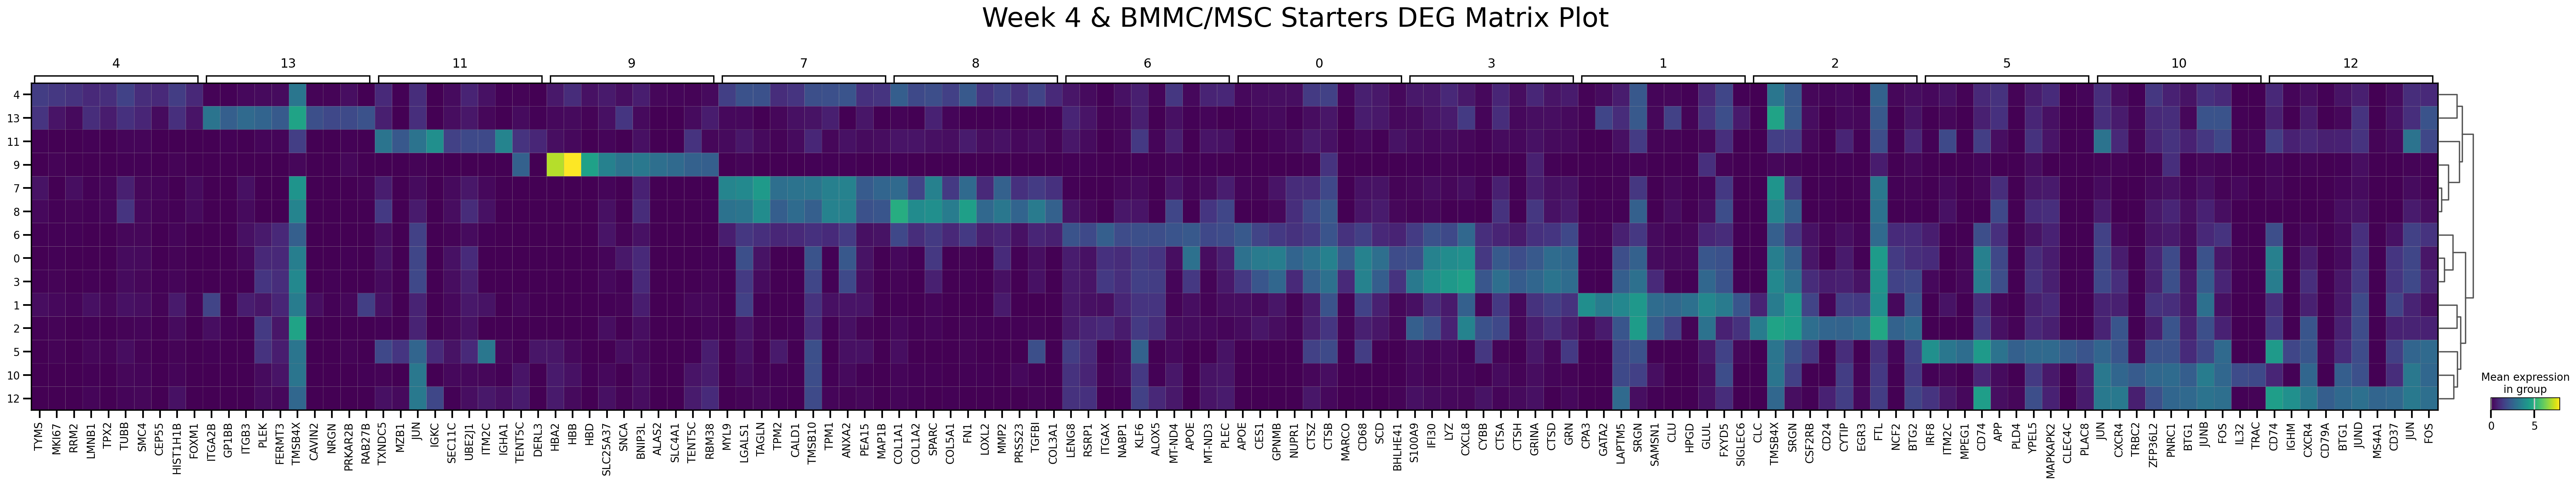

In [28]:
fig, ax = plt.subplots(1, 1, figsize=(50, 8), gridspec_kw={'hspace': 0.002})

sc.settings.set_figure_params(transparent=True)

sc.pl.rank_genes_groups_matrixplot(adata, n_genes=10, groupby="leiden", show=False, ax=ax)

ax.set_title('Week 4 & BMMC/MSC Starters DEG Matrix Plot', y=0.96, fontsize=30)

plt.savefig(pltdir + 'not_ds_trans_wk4_starters_deg_matrix_plot.png', transparent=True, bbox_inches='tight')
plt.savefig(pltdir + 'not_ds_wk4_starters_deg_matrix_plot.png', transparent=False, bbox_inches='tight')